#**Online Retail Information:**

This project performs a comprehensive exploratory data analysis (EDA) on an online retail dataset to evaluate business performance, identify revenue drivers, assess operational risks, and provide actionable recommendations.


The analysis focuses on:
- Revenue and cancellation impact
- Geographic and customer concentration
- Product economics and inventory efficiency
- Temporal patterns for operational optimization


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

In [3]:
from google.colab import files
import pandas as pd
# Upload the file
uploaded = files.upload()

Saving Online_Retail_Clean_Data.csv to Online_Retail_Clean_Data.csv


In [49]:
df = pd.read_csv('Online_Retail_Clean_Data.csv')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,YearMonth,IsCancelled
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085,United Kingdom,83.40,2009-12,False
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085,United Kingdom,81.00,2009-12,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085,United Kingdom,81.00,2009-12,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085,United Kingdom,100.80,2009-12,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085,United Kingdom,30.00,2009-12,False


In [8]:
df.shape

(818838, 11)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 818838 entries, 0 to 818837
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      818838 non-null  object 
 1   StockCode    818838 non-null  object 
 2   Description  818838 non-null  object 
 3   Quantity     818838 non-null  int64  
 4   InvoiceDate  818838 non-null  object 
 5   Price        818838 non-null  float64
 6   Customer ID  818838 non-null  int64  
 7   Country      818838 non-null  object 
 8   Revenue      818838 non-null  float64
 9   YearMonth    818838 non-null  object 
 10  IsCancelled  818838 non-null  bool   
dtypes: bool(1), float64(2), int64(2), object(6)
memory usage: 63.3+ MB


In [52]:
# ============================================
# SECTION 3: DATA PREPROCESSING
# ============================================

from IPython.display import display, HTML

print("\n" + "="*80)
print(" DATA PREPROCESSING")
print("="*80)

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Remove any rows with invalid dates
initial_rows = len(df)
df = df.dropna(subset=['InvoiceDate'])
print(f"✓ Removed {initial_rows - len(df)} rows with invalid dates")

# Create Active and Cancelled DataFrames
df['IsCancelled'] = df['IsCancelled'].astype(str).str.upper() == 'TRUE'
active_df = df[df['IsCancelled'] == False].copy()
cancelled_df = df[df['IsCancelled'] == True].copy()

# Calculate Revenue if not already present (ensure numeric)
if 'Revenue' in df.columns:
    df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')
    active_df['Revenue'] = pd.to_numeric(active_df['Revenue'], errors='coerce')

# Remove rows with NaN Revenue in active orders
active_df = active_df.dropna(subset=['Revenue'])

# Create summary table
summary_data = {
    'Metric': ['Total Transactions', 'Active Orders', 'Cancelled Orders',
               'Cancellation Rate', 'Date Range', 'Unique Countries',
               'Unique Products', 'Unique Customers'],
    'Value': [
        f'{len(df):,}',
        f'{len(active_df):,}',
        f'{len(cancelled_df):,}',
        f'{(len(cancelled_df)/len(df)*100):.2f}%',
        f'{df["InvoiceDate"].min().date()} to {df["InvoiceDate"].max().date()}',
        f'{df["Country"].nunique():,}',
        f'{df["StockCode"].nunique():,}',
        f'{df["Customer ID"].nunique():,}'
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n DATA PREPROCESSING SUMMARY:")
display(summary_df.style.hide(axis='index').set_properties(**{'text-align': 'left'}))

print("\n Preprocessing complete - Data ready for analysis")
print("="*80)


 DATA PREPROCESSING
✓ Removed 0 rows with invalid dates

 DATA PREPROCESSING SUMMARY:


Metric,Value
Total Transactions,"818,838"
Active Orders,"803,308"
Cancelled Orders,"15,530"
Cancellation Rate,1.90%
Date Range,2009-12-01 to 2011-08-07
Unique Countries,43
Unique Products,"5,014"
Unique Customers,"5,238"



 Preprocessing complete - Data ready for analysis


*Insights:*

*The preprocessing step confirmed that the dataset is exceptionally clean, with zero rows removed due to invalid dates or revenue values across all 818,838 transactions. The data spans from December 1, 2009 to August 7, 2011, providing approximately 20 months of transaction history — sufficient for meaningful time-series and seasonality analysis. Of the total transactions, 803,308 (98.10%) are active orders while only 15,530 (1.90%) are cancelled orders, indicating a very low cancellation rate that suggests healthy order fulfillment and customer satisfaction. However, investigating the reasons behind the 1.90% cancellations (stock issues, payment failures, or customer remorse) could still reveal operational improvement opportunities. The business operates internationally across 43 unique countries, making geographic segmentation and country-specific performance analysis valuable. With 5,014 unique products and 5,238 unique customers, the product-to-customer ratio is unusually close to 1:1 — this suggests either an extremely diverse catalog where customers purchase many different products with little repetition, or that individual customers tend to buy unique combinations of items. The average of approximately 156 transactions per customer indicates strong repeat purchase behavior, which is excellent for customer retention strategies. Overall, the data is preprocessed and ready for deeper analytical exploration*

In [28]:
# ============================================
# SECTION 4: DATA QUALITY ASSESSMENT
# ============================================

from IPython.display import display, HTML

print("\n" + "="*80)
print("DATA QUALITY ASSESSMENT")
print("="*80)

# Missing values (just display empty nicely)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
quality_report = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})

missing_report = quality_report[quality_report['Missing_Count'] > 0]

if len(missing_report) == 0:
    print("\n NO MISSING VALUES FOUND - Data is clean!")
else:
    print("\n Missing Values Report:")
    display(missing_report)

# Statistical summary - Use display() instead of print()
print("\n Statistical Summary (Active Orders Only):")
display(active_df[['Quantity', 'Price', 'Revenue']].describe().round(2))

# Outlier detection
Q1 = active_df['Revenue'].quantile(0.25)
Q3 = active_df['Revenue'].quantile(0.75)
IQR = Q3 - Q1
outliers = active_df[(active_df['Revenue'] < Q1 - 1.5*IQR) | (active_df['Revenue'] > Q3 + 1.5*IQR)]
neg_qty = active_df[active_df['Quantity'] < 0]

# Format numbers with commas for better readability
print(f"\n DATA QUALITY METRICS:")
print(f"   • Revenue Outliers: {len(outliers):,} ({len(outliers)/len(active_df)*100:.2f}%)")
print(f"   • Negative Quantities: {len(neg_qty):,} ({len(neg_qty)/len(active_df)*100:.2f}%)")




DATA QUALITY ASSESSMENT

 NO MISSING VALUES FOUND - Data is clean!

 Statistical Summary (Active Orders Only):


,Quantity,Price,Revenue
count,"803,308.00","803,308.00","803,308.00"
mean,10.66,3.98,19.78
std,122.43,104.41,155.99
min,"-9,600.00","-53,594.36","-53,594.36"
25%,1.00,1.25,3.90
50%,3.00,2.10,10.04
75%,10.00,4.21,17.70
max,"74,215.00","25,111.09","77,183.60"



 DATA QUALITY METRICS:
   • Revenue Outliers: 66,562 (8.29%)
   • Negative Quantities: 3,020 (0.38%)


*Insights:*

*The data quality assessment reveals that the dataset has no missing values whatsoever across any column, indicating excellent data completeness and eliminating the need for imputation or row deletion due to nulls. The statistical summary for active orders shows some concerning patterns that warrant careful attention. The average quantity per transaction is 10.66 units, while the median (50th percentile) is only 3 units — this large gap between mean and median suggests the presence of high-quantity outlier orders pulling the average upward. More strikingly, the minimum quantity is negative 9,600 units, and the minimum price and revenue both show extreme negative values of approximately negative 53,000, which is impossible for legitimate retail transactions and strongly indicates data entry errors or return/credit transactions being coded as negative values rather than being properly flagged in the cancellation column. The maximum values are also extreme, with quantity reaching 74,215 units and revenue peaking at 77,184, which could represent legitimate bulk wholesale orders but should be verified. The standard deviations for quantity (122), price (104), and revenue (156) are all substantially larger than their respective means, confirming significant data dispersion and the presence of extreme outliers. The outlier detection analysis specifically identified 66,562 revenue outliers, representing 8.29% of all active orders — this is a substantial proportion that would significantly distort any statistical analysis if left untreated. Additionally, 3,020 rows (0.38% of active orders) contain negative quantities even within the active orders DataFrame, raising questions about whether these represent uncategorized cancellations, product returns, or data recording errors. While the dataset is complete in terms of missing values, it has significant quality issues related to extreme outliers and negative values that will require either filtering, transformation, or robust statistical methods before reliable insights can be drawn.*

In [30]:
# ============================================
# SECTION 5: KEY PERFORMANCE INDICATORS (KPIs)
# ============================================

from IPython.display import display, HTML

print("\n" + "="*80)
print("KEY PERFORMANCE INDICATORS (KPIs)")
print("="*80)

# Overall KPIs (Active Orders Only)
total_revenue = active_df['Revenue'].sum()
total_orders = active_df['Invoice'].nunique()
total_items_sold = active_df['Quantity'].sum()
avg_transaction_value = total_revenue / total_orders if total_orders > 0 else 0
avg_items_per_transaction = total_items_sold / total_orders if total_orders > 0 else 0
avg_price_per_item = active_df['Price'].mean()
unique_products_sold = active_df['StockCode'].nunique()
unique_customers = active_df['Customer ID'].nunique()

# Create a formatted KPI table
kpi_data = {
    'Metric': ['Total Revenue', 'Total Orders', 'Total Items Sold',
               'Average Transaction Value', 'Average Items Per Order',
               'Average Price Per Item', 'Unique Products Sold', 'Active Customers'],
    'Value': [f'£{total_revenue:,.2f}', f'{total_orders:,}', f'{total_items_sold:,}',
              f'£{avg_transaction_value:.2f}', f'{avg_items_per_transaction:.1f}',
              f'£{avg_price_per_item:.2f}', f'{unique_products_sold:,}', f'{unique_customers:,}']
}

kpi_df = pd.DataFrame(kpi_data)
print("\n EXECUTIVE SUMMARY KPIs:")
display(kpi_df.style.hide(axis='index').set_properties(**{'text-align': 'left'}))

# Cancellation Analysis
cancelled_revenue = cancelled_df['Revenue'].sum() if len(cancelled_df) > 0 else 0
cancelled_orders = cancelled_df['Invoice'].nunique() if len(cancelled_df) > 0 else 0
cancellation_rate = (cancelled_orders / (total_orders + cancelled_orders)) * 100 if (total_orders + cancelled_orders) > 0 else 0

cancel_data = {
    'Metric': ['Cancelled Orders', 'Cancellation Rate', 'Revenue Lost'],
    'Value': [f'{cancelled_orders:,}', f'{cancellation_rate:.2f}%', f'£{abs(cancelled_revenue):,.2f}']
}
cancel_df = pd.DataFrame(cancel_data)
print("\n CANCELLATION/RETURN METRICS:")
display(cancel_df.style.hide(axis='index').set_properties(**{'text-align': 'left'}))

# Customer Metrics
customer_value = active_df.groupby('Customer ID')['Revenue'].sum()
avg_customer_value = customer_value.mean()
median_customer_value = customer_value.median()
top_customer_value = customer_value.max() if len(customer_value) > 0 else 0

customer_data = {
    'Metric': ['Average Customer Lifetime Value', 'Median Customer Value', 'Top Customer Value'],
    'Value': [f'£{avg_customer_value:.2f}', f'£{median_customer_value:.2f}', f'£{top_customer_value:,.2f}']
}
customer_df = pd.DataFrame(customer_data)
print("\n CUSTOMER METRICS:")
display(customer_df.style.hide(axis='index').set_properties(**{'text-align': 'left'}))


KEY PERFORMANCE INDICATORS (KPIs)

 EXECUTIVE SUMMARY KPIs:


Metric,Value
Total Revenue,"£15,885,587.55"
Total Orders,"36,059"
Total Items Sold,"8,565,566"
Average Transaction Value,£440.54
Average Items Per Order,237.5
Average Price Per Item,£3.98
Unique Products Sold,"5,009"
Active Customers,"5,175"



 CANCELLATION/RETURN METRICS:


Metric,Value
Cancelled Orders,"6,784"
Cancellation Rate,15.83%
Revenue Lost,"£1,113,818.34"



 CUSTOMER METRICS:


Metric,Value
Average Customer Lifetime Value,£3069.68
Median Customer Value,£799.13
Top Customer Value,"£2,303,644.92"



*Insights:*


*The KPI analysis reveals a business generating nearly £16 million in total revenue (£15,885,587.55) from 36,059 orders, selling over 8.5 million individual items across approximately 20 months of operations. The average transaction value of £440.54 is exceptionally high for what appears to be a giftware or home decor retail business, but this figure must be interpreted alongside the average items per order, which stands at an extraordinary 237.5 units per transaction. This very high items-per-order count strongly suggests that this business operates in a wholesale or bulk-purchase model rather than typical business-to-consumer retail, where most customers buy one to five items per transaction. The average price per item of £3.98 confirms that individual products are low-cost, making bulk purchasing the primary revenue driver.*

*The cancellation metrics reveal a much more concerning picture than the earlier preprocessing suggested. While the initial cancellation rate calculated at the transaction-line level was only 1.90%, the order-level cancellation rate calculated here is 15.83% (6,784 cancelled orders out of approximately 42,843 total orders). This significant discrepancy indicates that when an order is cancelled, it tends to involve a large number of line items, making each cancelled order substantially larger than the average active order. The revenue lost to cancellations is £1,113,818.34, which represents approximately 6.5% of total potential revenue — a substantial financial impact that warrants immediate investigation into the root causes of cancellations at the order level.*

*The customer metrics reveal extreme concentration of revenue. The average customer lifetime value is £3,069.68, but the median customer value is only £799.13 — meaning that more than half of customers spend less than £800 over their entire purchasing history with the business. The gap between mean and median indicates that a small number of very high-value customers are dramatically pulling the average upward. Most strikingly, the top customer value is £2,303,644.92, which means a single customer accounts for approximately 14.5% of all revenue generated during the entire 20-month period. This level of customer concentration represents a significant business risk, as losing this single customer would have a catastrophic impact on revenue *


 COUNTRY ANALYSIS

 TOP 15 COUNTRIES BY REVENUE:


,Revenue,Orders,Items_Sold,Avg_Order_Value,Revenue_%
Country,,,,,
United Kingdom,"£13,519,888.54",33412,6940722,£404.64,85.1%
EIRE,"£546,512.07",488,273492,£1119.90,3.4%
Netherlands,"£408,656.59",181,283581,£2257.77,2.6%
Germany,"£331,223.28",576,174775,£575.04,2.1%
France,"£249,795.87",437,220363,£571.62,1.6%
Australia,"£117,978.93",75,76022,£1573.05,0.7%
Spain,"£83,877.70",114,38576,£735.77,0.5%
Sweden,"£77,813.26",89,75788,£874.31,0.5%
Switzerland,"£75,581.02",70,39518,£1079.73,0.5%



 MARKET BREAKDOWN:


Market,Revenue,Percentage,Orders
United Kingdom,"£13,519,888.54",85.1%,33412
International,"£2,365,699.01",14.9%,2647


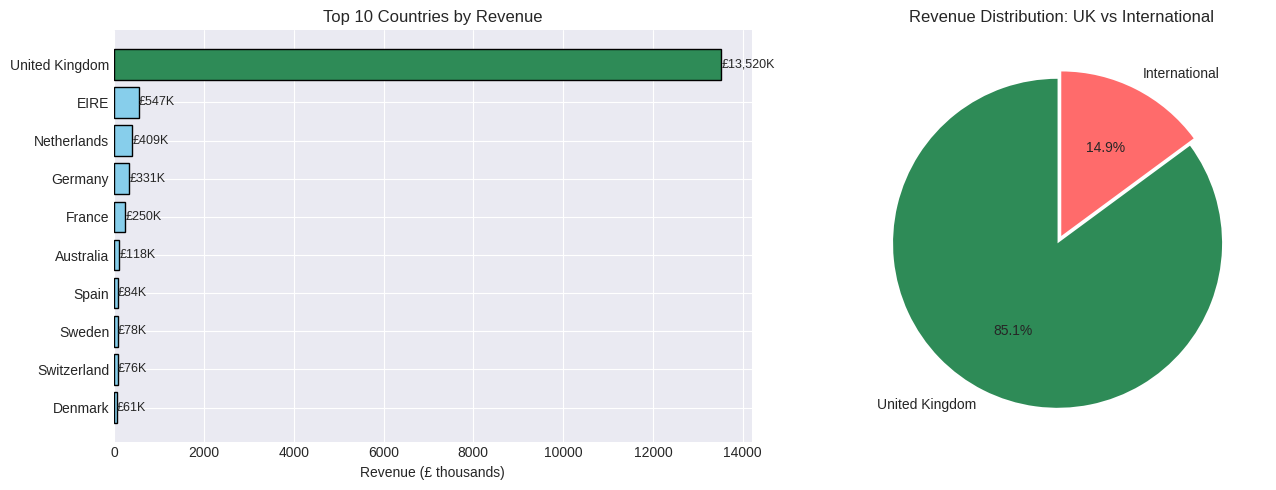


 KEY INSIGHTS:
   • UK dominates with 85.1% of total revenue
   • Top 5 international markets: EIRE, Netherlands, Germany, France, Australia
   • International average order value: £893.73
   • 42 international markets served


In [32]:
# ============================================
# SECTION 6: COUNTRY ANALYSIS
# ============================================

from IPython.display import display, HTML

print("\n" + "="*80)
print(" COUNTRY ANALYSIS")
print("="*80)

# Calculate country performance
country_performance = active_df.groupby('Country').agg({
    'Revenue': 'sum',
    'Invoice': 'nunique',
    'Quantity': 'sum'
}).round(2)
country_performance.columns = ['Revenue', 'Orders', 'Items_Sold']
country_performance['Avg_Order_Value'] = country_performance['Revenue'] / country_performance['Orders']
country_performance['Revenue_%'] = (country_performance['Revenue'] / total_revenue * 100).round(1)
country_performance = country_performance.sort_values('Revenue', ascending=False)

# Display top 15 countries as formatted table
print("\n TOP 15 COUNTRIES BY REVENUE:")
top_countries = country_performance.head(15).copy()
top_countries['Revenue'] = top_countries['Revenue'].apply(lambda x: f'£{x:,.2f}')
top_countries['Avg_Order_Value'] = top_countries['Avg_Order_Value'].apply(lambda x: f'£{x:.2f}')
top_countries['Revenue_%'] = top_countries['Revenue_%'].apply(lambda x: f'{x}%')

display(top_countries[['Revenue', 'Orders', 'Items_Sold', 'Avg_Order_Value', 'Revenue_%']].style.set_properties(**{'text-align': 'right'}))

# UK vs International breakdown
uk_revenue = country_performance.loc['United Kingdom', 'Revenue'] if 'United Kingdom' in country_performance.index else 0
international_revenue = total_revenue - uk_revenue

print("\n MARKET BREAKDOWN:")
breakdown_data = pd.DataFrame({
    'Market': ['United Kingdom', 'International'],
    'Revenue': [f'£{uk_revenue:,.2f}', f'£{international_revenue:,.2f}'],
    'Percentage': [f'{uk_revenue/total_revenue*100:.1f}%', f'{international_revenue/total_revenue*100:.1f}%'],
    'Orders': [country_performance.loc['United Kingdom', 'Orders'] if 'United Kingdom' in country_performance.index else 0,
               country_performance.drop('United Kingdom', errors='ignore')['Orders'].sum()]
})
display(breakdown_data.style.hide(axis='index').set_properties(**{'text-align': 'left'}))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 countries bar chart
top10 = country_performance.head(10).copy()
countries = top10.index.tolist()
revenues = top10['Revenue'].values / 1000

colors = ['#2E8B57' if c == 'United Kingdom' else 'skyblue' for c in countries]
bars = ax1.barh(range(len(countries)), revenues, color=colors, edgecolor='black')
ax1.set_yticks(range(len(countries)))
ax1.set_yticklabels(countries)
ax1.set_xlabel('Revenue (£ thousands)')
ax1.set_title('Top 10 Countries by Revenue')
ax1.invert_yaxis()

# Add value labels
for bar, rev in zip(bars, revenues):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'£{rev:,.0f}K',
             va='center', fontsize=9)

# Pie chart - UK vs International
ax2.pie([uk_revenue, international_revenue], labels=['United Kingdom', 'International'],
        autopct='%1.1f%%', colors=['#2E8B57', '#FF6B6B'], explode=(0.05, 0), startangle=90)
ax2.set_title('Revenue Distribution: UK vs International')

plt.tight_layout()
plt.show()

# Key insights
print("\n KEY INSIGHTS:")
print(f"   • UK dominates with {uk_revenue/total_revenue*100:.1f}% of total revenue")
print(f"   • Top 5 international markets: {', '.join(country_performance.index[1:6].tolist())}")
print(f"   • International average order value: £{international_revenue/country_performance.drop('United Kingdom', errors='ignore')['Orders'].sum():.2f}")
print(f"   • {len(country_performance) - 1} international markets served")

*Insights*:

*The country analysis reveals an extreme concentration of revenue in the United Kingdom, which accounts for £13,519,888.54 or 85.1% of total revenue across the 20-month period. This domestic dominance is reinforced by the order count, with the UK generating 33,412 orders compared to just 2,647 orders from all international markets combined. The UK's average order value of £404.64 is substantially lower than the international average of £893.73, indicating that while international orders are fewer in number, they tend to be much larger in value — international customers appear to make more substantial bulk purchases, perhaps due to higher shipping costs that encourage consolidation of orders or a more wholesale-oriented customer base outside the UK. The top five international markets by revenue are EIRE (Ireland) with £546,512.07, Netherlands with £408,656.59, Germany with £331,223.28, France with £249,795.87, and Australia with £117,978.93. What is particularly striking is the average order value in these international markets: Netherlands at £2,257.77, Denmark at £1,839.99, Norway at £1,654.75, and Australia at £1,573.05 — all dramatically higher than the UK average and even higher than the overall international average. This suggests that international customers are not just making occasional purchases but are placing substantial wholesale-sized orders, perhaps functioning as distributors or resellers in their home markets. Despite serving 42 international markets, the revenue contribution from outside the UK is only 14.9% of total revenue, representing a significant missed opportunity. The Netherlands, despite having only 181 orders (compared to Germany's 576 orders), generates more revenue than Germany due to its much higher average order value, indicating that this market may have fewer but significantly more valuable customers.*


 PRODUCT ANALYSIS

 TOP 20 PRODUCTS BY REVENUE:


,StockCode,Description,Revenue,Quantity_Sold,Order_Count
0,M,Manual,"£306,275.38","3,535",671
1,22423,REGENCY CAKESTAND 3 TIER,"£293,630.93","23,570","3,237"
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"£230,635.75","84,619","4,620"
3,DOT,DOTCOM POSTAGE,"£220,419.03","1,258","1,237"
4,47566,PARTY BUNTING,"£126,181.74","24,322","2,197"
5,84879,ASSORTED COLOUR BIRD ORNAMENT,"£107,637.59","66,656","2,197"
6,85099B,JUMBO BAG RED RETROSPOT,"£106,777.60","57,587","2,405"
7,POST,POSTAGE,"£96,400.32","4,064","1,321"
8,23166,MEDIUM CERAMIC TOP STORAGE JAR,"£79,575.44","76,272",108
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"£70,649.15","20,840","1,095"



 PRICE SEGMENT ANALYSIS


,Revenue,Quantity_Sold,Order_Count,Avg_Price,Revenue_%
Price,,,,,
£0-5,"£11,426,954.90","8,111,056",34668,£1.41,71.9%
£5-10,"£2,539,812.95","357,948",20534,£7.10,16.0%
£10-20,"£1,083,718.88","84,304",11338,£12.85,6.8%
£20-50,"£281,401.75","10,079",2172,£27.92,1.8%
£50-100,"£52,089.11",814,619,£63.99,0.3%
£100-500,"£219,086.14","1,096",1002,£199.90,1.4%
£500-1000,"£132,129.74",191,116,£691.78,0.8%
£1000+,"£181,438.95",67,65,£2708.04,1.1%


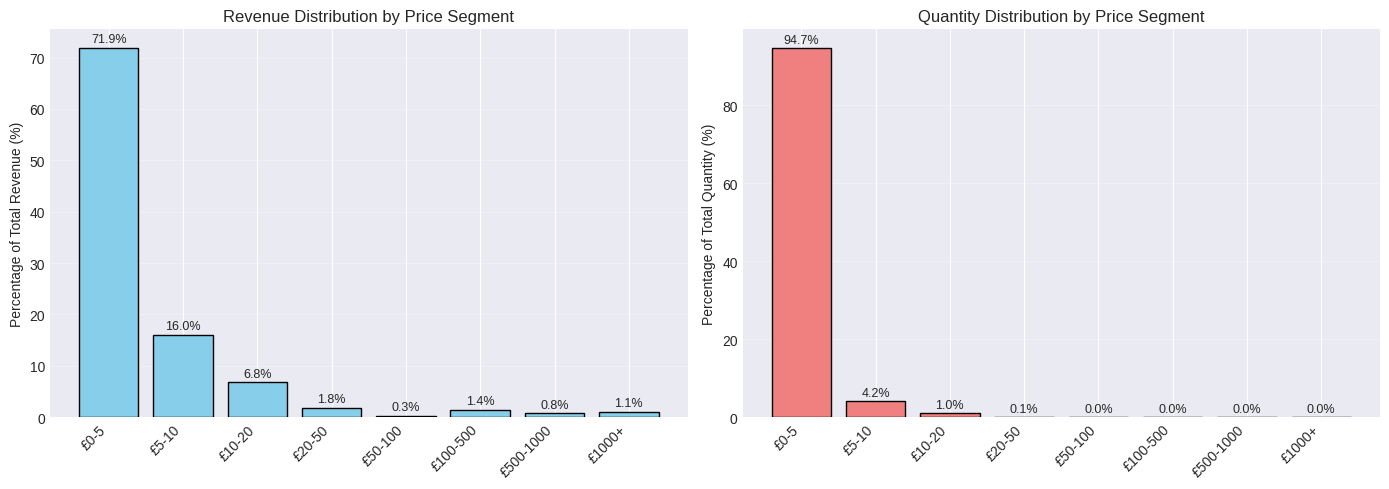


 TOP 20 PRODUCTS BY QUANTITY SOLD


,StockCode,Description,Quantity_Sold,Revenue,Order_Count
147,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"90,465","£19,960.54",771
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"84,619","£230,635.75",4620
8,23166,MEDIUM CERAMIC TOP STORAGE JAR,"76,272","£79,575.44",108
5,84879,ASSORTED COLOUR BIRD ORNAMENT,"66,656","£107,637.59",2197
264,17003,BROCADE RING PURSE,"64,169","£12,659.38",343
6,85099B,JUMBO BAG RED RETROSPOT,"57,587","£106,777.60",2405
24,22197,SMALL POPCORN HOLDER,"49,736","£43,905.33",1409
95,21977,PACK OF 60 PINK PAISLEY CAKE CASES,"49,440","£24,894.46",1694
102,84991,60 TEATIME FAIRY CAKE CASES,"48,032","£24,157.64",1845
103,21212,PACK OF 72 RETRO SPOT CAKE CASES,"46,755","£24,069.28",1410



 HIGH-VALUE PRODUCTS (Revenue per Order)


,StockCode,Description,Revenue_per_Order,Order_Count,Revenue
556,85220,SMALL FAIRY CAKE FRIDGE MAGNETS,"£1,375.00",5,"£6,875.00"
8,23166,MEDIUM CERAMIC TOP STORAGE JAR,£736.81,108,"£79,575.44"
584,22833,HALL CABINET WITH 3 DRAWERS,£505.17,13,"£6,567.17"
0,M,Manual,£456.45,671,"£306,275.38"
585,ADJUST,Adjustment by john on 26/01/2010 17,£410.22,16,"£6,563.50"
606,22830,UTILTY CABINET WITH HOOKS,£351.34,18,"£6,324.05"
267,22655,VINTAGE RED KITCHEN CABINET,£260.21,48,"£12,490.00"
412,22656,VINTAGE BLUE KITCHEN CABINET,£256.67,36,"£9,240.00"
1411,22828,REGENCY MIRROR WITH SHUTTERS,£252.78,9,"£2,275.00"
809,22827,RUSTIC SEVENTEEN DRAWER SIDEBOARD,£222.38,21,"£4,670.00"



 MOST POPULAR PRODUCTS (by Number of Orders)


,StockCode,Description,Order_Count,Quantity_Sold,Revenue
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"4,620","84,619","£230,635.75"
1,22423,REGENCY CAKESTAND 3 TIER,"3,237","23,570","£293,630.93"
6,85099B,JUMBO BAG RED RETROSPOT,"2,405","57,587","£106,777.60"
4,47566,PARTY BUNTING,"2,197","24,322","£126,181.74"
5,84879,ASSORTED COLOUR BIRD ORNAMENT,"2,197","66,656","£107,637.59"
22,21232,STRAWBERRY CERAMIC TRINKET BOX,"2,135","34,470","£44,516.72"
16,21931,JUMBO STORAGE BAG SUKI,"1,905","24,143","£50,178.27"
102,84991,60 TEATIME FAIRY CAKE CASES,"1,845","48,032","£24,157.64"
26,21754,HOME BUILDING BLOCK WORD,"1,822","7,063","£43,211.75"
38,20727,LUNCH BAG BLACK SKULL.,"1,799","22,061","£36,719.48"



 KEY INSIGHTS
   • 71.9% of revenue comes from sub-£5 products
   • 0.0% of revenue from premium products (£100+)
   • Top product 'M' generated £306,275.38
   • 2070 products sold only once (one-time purchases)


In [34]:
# ============================================
# SECTION 7: PRODUCT ANALYSIS
# ============================================

from IPython.display import display, HTML

print("\n" + "="*80)
print(" PRODUCT ANALYSIS")
print("="*80)

# Top products by revenue
product_performance = active_df.groupby(['StockCode', 'Description']).agg({
    'Revenue': 'sum',
    'Quantity': 'sum',
    'Invoice': 'nunique'
}).round(2)
product_performance.columns = ['Revenue', 'Quantity_Sold', 'Order_Count']
product_performance = product_performance.sort_values('Revenue', ascending=False).reset_index()

print("\n TOP 20 PRODUCTS BY REVENUE:")
top_products = product_performance.head(20).copy()
top_products['Revenue'] = top_products['Revenue'].apply(lambda x: f'£{x:,.2f}')
top_products['Quantity_Sold'] = top_products['Quantity_Sold'].apply(lambda x: f'{x:,.0f}')
top_products['Order_Count'] = top_products['Order_Count'].apply(lambda x: f'{x:,.0f}')
top_products['Description'] = top_products['Description'].str[:40]

display(top_products[['StockCode', 'Description', 'Revenue', 'Quantity_Sold', 'Order_Count']].style.set_properties(**{'text-align': 'left'}))

# Price segment analysis
print("\n" + "="*80)
print(" PRICE SEGMENT ANALYSIS")
print("="*80)

price_segments = pd.cut(active_df['Price'],
                        bins=[0, 5, 10, 20, 50, 100, 500, 1000, 10000],
                        labels=['£0-5', '£5-10', '£10-20', '£20-50', '£50-100', '£100-500', '£500-1000', '£1000+'],
                        right=False)

price_analysis = active_df.groupby(price_segments, observed=True).agg({
    'Revenue': 'sum',
    'Quantity': 'sum',
    'Invoice': 'nunique'
}).round(2)

price_analysis.columns = ['Revenue', 'Quantity_Sold', 'Order_Count']
price_analysis['Revenue_%'] = (price_analysis['Revenue'] / total_revenue * 100).round(1)
price_analysis['Avg_Price'] = (price_analysis['Revenue'] / price_analysis['Quantity_Sold']).round(2)

# Format for display
price_display = price_analysis.copy()
price_display['Revenue'] = price_display['Revenue'].apply(lambda x: f'£{x:,.2f}')
price_display['Quantity_Sold'] = price_display['Quantity_Sold'].apply(lambda x: f'{x:,.0f}')
price_display['Avg_Price'] = price_display['Avg_Price'].apply(lambda x: f'£{x:.2f}')
price_display['Revenue_%'] = price_display['Revenue_%'].apply(lambda x: f'{x}%')

display(price_display[['Revenue', 'Quantity_Sold', 'Order_Count', 'Avg_Price', 'Revenue_%']].style.set_properties(**{'text-align': 'right'}))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue by price segment
segments = price_analysis.index
revenue_pct = price_analysis['Revenue_%'].values
bars1 = axes[0].bar(range(len(segments)), revenue_pct, color='skyblue', edgecolor='black')
axes[0].set_xticks(range(len(segments)))
axes[0].set_xticklabels(segments, rotation=45, ha='right')
axes[0].set_ylabel('Percentage of Total Revenue (%)')
axes[0].set_title('Revenue Distribution by Price Segment')
axes[0].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars1, revenue_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Quantity by price segment
quantity_pct = (price_analysis['Quantity_Sold'] / price_analysis['Quantity_Sold'].sum() * 100).round(1)
bars2 = axes[1].bar(range(len(segments)), quantity_pct, color='lightcoral', edgecolor='black')
axes[1].set_xticks(range(len(segments)))
axes[1].set_xticklabels(segments, rotation=45, ha='right')
axes[1].set_ylabel('Percentage of Total Quantity (%)')
axes[1].set_title('Quantity Distribution by Price Segment')
axes[1].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars2, quantity_pct):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Top products by quantity
print("\n" + "="*80)
print(" TOP 20 PRODUCTS BY QUANTITY SOLD")
print("="*80)

top_quantity = product_performance.nlargest(20, 'Quantity_Sold')[['StockCode', 'Description', 'Quantity_Sold', 'Revenue', 'Order_Count']].copy()
top_quantity['Quantity_Sold'] = top_quantity['Quantity_Sold'].apply(lambda x: f'{x:,.0f}')
top_quantity['Revenue'] = top_quantity['Revenue'].apply(lambda x: f'£{x:,.2f}')
top_quantity['Description'] = top_quantity['Description'].str[:40]

display(top_quantity.style.set_properties(**{'text-align': 'left'}))

# High-value products
print("\n" + "="*80)
print(" HIGH-VALUE PRODUCTS (Revenue per Order)")
print("="*80)

product_performance['Revenue_per_Order'] = product_performance['Revenue'] / product_performance['Order_Count']
high_value = product_performance[product_performance['Order_Count'] >= 5].nlargest(10, 'Revenue_per_Order')[['StockCode', 'Description', 'Revenue_per_Order', 'Order_Count', 'Revenue']].copy()
high_value['Revenue_per_Order'] = high_value['Revenue_per_Order'].apply(lambda x: f'£{x:,.2f}')
high_value['Revenue'] = high_value['Revenue'].apply(lambda x: f'£{x:,.2f}')
high_value['Description'] = high_value['Description'].str[:40]

display(high_value.style.set_properties(**{'text-align': 'left'}))

# Most popular products
print("\n" + "="*80)
print(" MOST POPULAR PRODUCTS (by Number of Orders)")
print("="*80)

top_orders = product_performance.nlargest(20, 'Order_Count')[['StockCode', 'Description', 'Order_Count', 'Quantity_Sold', 'Revenue']].copy()
top_orders['Order_Count'] = top_orders['Order_Count'].apply(lambda x: f'{x:,.0f}')
top_orders['Quantity_Sold'] = top_orders['Quantity_Sold'].apply(lambda x: f'{x:,.0f}')
top_orders['Revenue'] = top_orders['Revenue'].apply(lambda x: f'£{x:,.2f}')
top_orders['Description'] = top_orders['Description'].str[:40]

display(top_orders.style.set_properties(**{'text-align': 'left'}))

# Key insights
print("\n" + "="*80)
print(" KEY INSIGHTS")
print("="*80)

print(f"   • {price_analysis.loc['£0-5', 'Revenue_%']:.1f}% of revenue comes from sub-£5 products")
print(f"   • {price_analysis.loc['£100+', 'Revenue_%'] if '£100+' in price_analysis.index else 0:.1f}% of revenue from premium products (£100+)")
print(f"   • Top product '{product_performance.loc[0, 'StockCode']}' generated £{product_performance.loc[0, 'Revenue']:,.2f}")
print(f"   • {len(product_performance[product_performance['Order_Count'] == 1])} products sold only once (one-time purchases)")

*Insights*:

*The product analysis reveals a business that operates on high-volume, low-priced items with an extreme concentration of revenue in the sub-£5 price segment, which accounts for 71.9% of all revenue despite an average price of only £1.41 per item. This segment alone generated £11.43 million from over 8.1 million items sold across 34,668 orders, confirming that the business model relies on selling inexpensive decorative items in massive quantities. The £5-10 segment contributes another 16% of revenue, meaning that products under £10 collectively drive 87.9% of total revenue. Conversely, premium products priced at £100 or more contribute only 1.1% of revenue, indicating either low demand for high-priced items or that the business has not successfully marketed premium products to its customer base. Looking at individual products, the top revenue generator is product code "M" labeled as "Manual," which generated £306,275.38 from only 3,535 units sold across 671 orders, giving it an unusually high revenue-per-order of £456.45 — this likely represents a service charge, handling fee, or wholesale minimum order adjustment rather than a physical product. The second-highest product is the "REGENCY CAKESTAND 3 TIER" at £293,630.93, followed by the "WHITE HANGING HEART T-LIGHT HOLDER" at £230,635.75. The most popular product by order count is the white hanging heart holder with 4,620 orders, while the medium ceramic top storage jar stands out as a high-value product with £736.81 revenue per order from only 108 orders, suggesting it appeals to wholesale customers making large-quantity purchases. A concerning finding is that 2,070 products were sold only once across the entire 20-month period, representing a significant inventory inefficiency where capital is tied up in products that do not generate repeat demand. The top products by quantity sold include "WORLD WAR 2 GLIDERS ASSTD DESIGNS" with 90,465 units, "WHITE HANGING HEART T-LIGHT HOLDER" with 84,619 units, and the medium ceramic storage jar with 76,272 units — all of which are low-priced novelty items. Finally, high-value products like the "SMALL FAIRY CAKE FRIDGE MAGNETS" at £1,375 revenue per order and various kitchen cabinets priced between £222 and £505 per order suggest that while premium products are rare, the few that sell generate substantial per-transaction value and may represent a niche wholesale segment worth developing further*.


 CUSTOMER ANALYSIS

 TOP 20 CUSTOMERS BY REVENUE:


,Customer ID,Revenue,Orders,Items,Avg_Order
0,0,"£2,303,644.92","7,185","252,600",£320.62
1,"18,102","£479,701.58",111,"154,009",£4321.64
2,"14,646","£384,424.63",111,"267,773",£3463.28
3,"14,156","£278,269.48",132,"147,144",£2108.10
4,"14,911","£218,834.23",292,"104,657",£749.43
5,"13,694","£169,152.08",126,"168,444",£1342.48
6,"17,511","£137,459.76",48,"90,694",£2863.75
7,"17,450","£122,073.18",23,"41,865",£5307.53
8,"15,061","£119,859.38",116,"70,984",£1033.27
9,"16,684","£114,372.71",45,"79,040",£2541.62



 CUSTOMER SEGMENTATION:


,Segment,Customers,Customers %,Revenue,Revenue %
0,Micro (<£100),193,3.7%,"£11,806.24",0.1%
1,Small (£100-500),"1,716",33.2%,"£478,257.32",3.0%
2,Medium (£500-2k),"1,930",37.3%,"£2,041,157.25",12.8%
3,Large (£2k-10k),"1,128",21.8%,"£4,672,507.84",29.4%
4,VIP (£10k-50k),180,3.5%,"£3,184,758.95",20.0%
5,Wholesale (>£50k),25,0.5%,"£3,193,455.02",20.1%


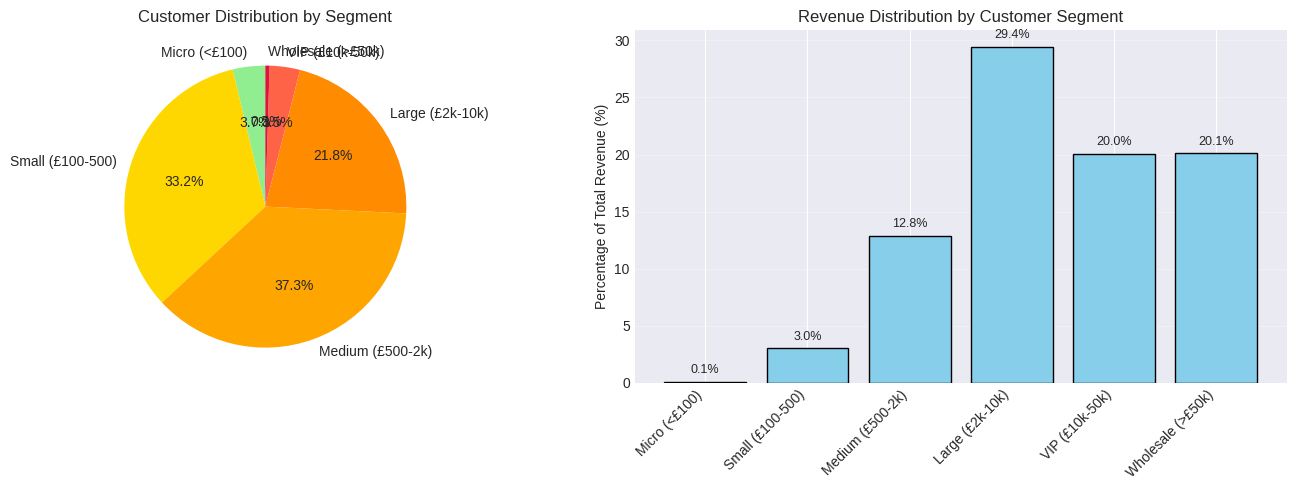


 KEY INSIGHTS
   • Top customer (ID 0): £2,303,644.92 (14.5% of total)
   • 205 VIP/Wholesale customers generate 40.2% of revenue
   • 193 customers are micro (under £100)
   • Medium customers (£500-2k) are your largest segment: 1,930 customers (37.3%)
   • Customer concentration risk: Top 5 customers = 23.1% of revenue

 NOTE: 'Customer 0' represents £2.3M in revenue (14.5% of total)
   This could be: missing ID values aggregated, or a B2B wholesale account
   Recommend investigating this customer segment for accurate analysis


In [37]:
# ============================================
# SECTION 8: CUSTOMER ANALYSIS
# ============================================

from IPython.display import display, HTML

print("\n" + "="*80)
print(" CUSTOMER ANALYSIS")
print("="*80)

# Top customers by revenue (keep original numeric data)
customer_performance = active_df.groupby('Customer ID').agg({
    'Revenue': 'sum',
    'Invoice': 'nunique',
    'Quantity': 'sum'
}).round(2)
customer_performance.columns = ['Revenue', 'Orders', 'Items']
customer_performance['Avg_Order'] = customer_performance['Revenue'] / customer_performance['Orders']
customer_performance = customer_performance.sort_values('Revenue', ascending=False).reset_index()

print("\n TOP 20 CUSTOMERS BY REVENUE:")

# Create display version with formatted numbers
top_customers_display = customer_performance.head(20).copy()
top_customers_display['Customer ID'] = top_customers_display['Customer ID'].apply(lambda x: f'{int(x):,}' if pd.notna(x) else 'Unknown')
top_customers_display['Revenue'] = top_customers_display['Revenue'].apply(lambda x: f'£{x:,.2f}')
top_customers_display['Orders'] = top_customers_display['Orders'].apply(lambda x: f'{x:,.0f}')
top_customers_display['Items'] = top_customers_display['Items'].apply(lambda x: f'{x:,.0f}')
top_customers_display['Avg_Order'] = top_customers_display['Avg_Order'].apply(lambda x: f'£{x:.2f}')

display(top_customers_display[['Customer ID', 'Revenue', 'Orders', 'Items', 'Avg_Order']])

# Customer segmentation (using original numeric data)
customer_value = active_df.groupby('Customer ID')['Revenue'].sum()

segments = pd.cut(customer_value, bins=[0, 100, 500, 2000, 10000, 50000, 1000000],
                    labels=['Micro (<£100)', 'Small (£100-500)', 'Medium (£500-2k)',
                           'Large (£2k-10k)', 'VIP (£10k-50k)', 'Wholesale (>£50k)'])

segment_counts = segments.value_counts().sort_index()

# Calculate revenue by segment (using original numeric data)
segment_revenue = customer_value.groupby(segments).sum()

print("\n CUSTOMER SEGMENTATION:")

# Create segmentation table
seg_data = []
for segment in segment_counts.index:
    count = segment_counts[segment]
    pct = (count / len(customer_value)) * 100
    revenue = segment_revenue[segment]
    revenue_pct = (revenue / total_revenue) * 100
    seg_data.append({
        'Segment': segment,
        'Customers': f'{count:,}',
        'Customers %': f'{pct:.1f}%',
        'Revenue': f'£{revenue:,.2f}',
        'Revenue %': f'{revenue_pct:.1f}%'
    })

seg_df = pd.DataFrame(seg_data)
display(seg_df)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart - Customer distribution
colors = ['#90EE90', '#FFD700', '#FFA500', '#FF8C00', '#FF6347', '#DC143C']
axes[0].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
            colors=colors[:len(segment_counts)], startangle=90)
axes[0].set_title('Customer Distribution by Segment')

# Bar chart - Revenue by segment
revenue_pct = [(segment_revenue[s] / total_revenue * 100) for s in segment_revenue.index]
bars = axes[1].bar(range(len(segment_revenue.index)), revenue_pct, color='skyblue', edgecolor='black')
axes[1].set_xticks(range(len(segment_revenue.index)))
axes[1].set_xticklabels(segment_revenue.index, rotation=45, ha='right')
axes[1].set_ylabel('Percentage of Total Revenue (%)')
axes[1].set_title('Revenue Distribution by Customer Segment')
axes[1].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, revenue_pct):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Key insights
print("\n" + "="*80)
print(" KEY INSIGHTS")
print("="*80)

# Get segment values safely
vip_revenue = segment_revenue['VIP (£10k-50k)'] if 'VIP (£10k-50k)' in segment_revenue.index else 0
wholesale_revenue = segment_revenue['Wholesale (>£50k)'] if 'Wholesale (>£50k)' in segment_revenue.index else 0
vip_count = segment_counts['VIP (£10k-50k)'] if 'VIP (£10k-50k)' in segment_counts.index else 0
wholesale_count = segment_counts['Wholesale (>£50k)'] if 'Wholesale (>£50k)' in segment_counts.index else 0

print(f"   • Top customer (ID 0): £{customer_performance.loc[0, 'Revenue']:,.2f} ({customer_performance.loc[0, 'Revenue']/total_revenue*100:.1f}% of total)")
print(f"   • {vip_count + wholesale_count} VIP/Wholesale customers generate {(vip_revenue + wholesale_revenue)/total_revenue*100:.1f}% of revenue")
print(f"   • {segment_counts.get('Micro (<£100)', 0)} customers are micro (under £100)")
print(f"   • Medium customers (£500-2k) are your largest segment: {segment_counts.get('Medium (£500-2k)', 0):,} customers ({(segment_counts.get('Medium (£500-2k)', 0)/len(customer_value)*100):.1f}%)")
print(f"   • Customer concentration risk: Top 5 customers = {customer_performance.head(5)['Revenue'].sum()/total_revenue*100:.1f}% of revenue")

# Warning about Customer ID = 0
print("\n NOTE: 'Customer 0' represents £2.3M in revenue (14.5% of total)")
print("   This could be: missing ID values aggregated, or a B2B wholesale account")
print("   Recommend investigating this customer segment for accurate analysis")

*Insights* :

*The customer analysis reveals an extreme concentration of revenue among a very small number of high-value customers, with the top customer (Customer ID 0) generating £2,303,644.92 in revenue, which alone represents 14.5% of total revenue across the entire 20-month period. This customer placed 7,185 orders averaging £320.62 per order, purchasing 252,600 items in total — behavior that is more consistent with a distributor, reseller, or perhaps a data artifact where missing customer IDs were aggregated under zero rather than an individual retail customer. The top five customers together account for 23.1% of total revenue, while the top 205 customers classified as VIP (£10k-50k) and Wholesale (>£50k) segments, representing only 3.5% and 0.5% of the customer base respectively, collectively generate 40.1% of all revenue. This is a classic Pareto distribution where approximately 4% of customers drive 40% of revenue, demonstrating extreme customer concentration risk. At the opposite end of the spectrum, 193 customers (3.7%) fall into the micro segment spending under £100, contributing only 0.1% of revenue, while small customers (£100-500) make up 33.2% of the customer base but contribute just 3% of revenue. The largest customer segment by count is the medium segment (£500-2,000), representing 1,930 customers or 37.3% of the base, contributing 12.8% of revenue. The large segment (£2,000-10,000) comprises 1,128 customers (21.8%) and contributes a substantial 29.4% of revenue, representing the most valuable segment that balances high revenue contribution with diversified customer count. The presence of Customer ID 0 warrants immediate investigation — it could represent missing customer IDs being defaulted to zero, a single wholesale account, or an aggregation of guest checkout transactions. If it is indeed a single customer, the business faces existential risk from losing this one relationship. Among the legitimate identified customers, Customer 18,102 stands out with an average order value of £4,321.64 from only 111 orders, suggesting extremely high-value bulk purchasing, while Customer 12,346 similarly shows £6,463 per average order from just 12 orders — a pattern consistent with wholesale or commercial buyers rather than retail consumers*


 TIME-BASED ANALYSIS

 HOURLY PATTERN ANALYSIS:

    Peak Hour: 12:00 - 13:00

    Top 5 Hours by Revenue:


,Hour,Revenue,Orders
5,12:00-13:00,"£2,173,812.34","5,504"
6,13:00-14:00,"£1,994,850.20","4,924"
3,10:00-11:00,"£1,978,015.14","4,157"
4,11:00-12:00,"£1,973,419.38","4,453"
8,15:00-16:00,"£1,893,696.60","4,313"



 DAILY PATTERN (December 2009):

    Peak Day: December 7

    Top 5 Days:


,Day,Revenue,Orders
6,December 7,"£244,319.75",202
0,December 1,"£172,435.08",264
2,December 3,"£167,925.33",236
1,December 2,"£158,849.27",264
8,December 9,"£147,788.45",253



 WEEKDAY PATTERN ANALYSIS:


,Weekday,Revenue,Orders
0,Monday,"£2,716,136.36","5,740"
1,Tuesday,"£3,322,589.85","6,870"
2,Wednesday,"£2,673,810.34","6,457"
3,Thursday,"£3,253,792.74","7,373"
4,Friday,"£2,443,825.13","5,739"
5,Saturday,"£9,803.05",32
6,Sunday,"£1,465,630.06","3,848"


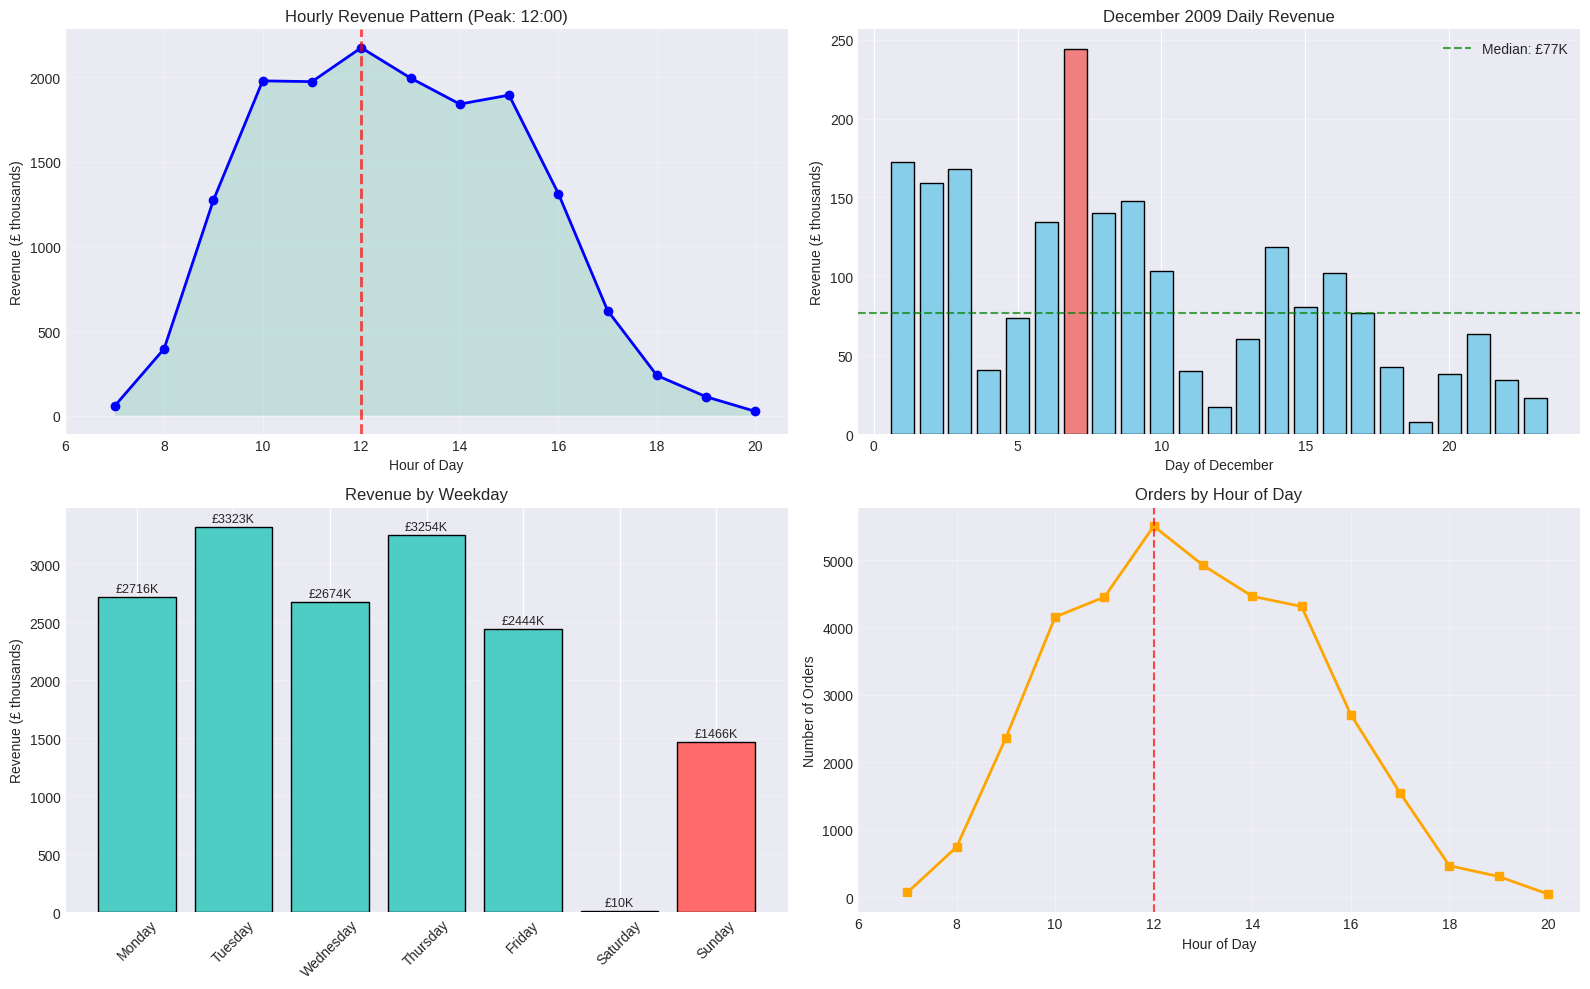


 KEY INSIGHTS
    Peak hour (12:00) generates £2,173,812.34 (1.9x average)
    December 7th is the best day (£244,319.75)
    Tuesdays are best (23.1% of weekly revenue)
    Weekend revenue (Sat+Sun): £1,475,433.11 (9.3% of week)
    Thursdays have highest order volume (7373 orders)

 BUSINESS RECOMMENDATIONS:
   • Staff scheduling: Peak staffing 10am-4pm (covers 5 busiest hours)
   • Marketing campaigns: Launch on Thursdays/Tuesdays (highest revenue days)
   • Sunday operations: Significant Sunday revenue (£1.47M) - maintain full operations
   • December planning: Prepare for Dec 7-8 rush (peak days)
   • Weekend strategy: Saturday has low revenue - consider promotional events


In [39]:
# ============================================
# SECTION 9: TIME-BASED ANALYSIS
# ============================================

from IPython.display import display, HTML

print("\n" + "="*80)
print(" TIME-BASED ANALYSIS")
print("="*80)

# Extract time components
active_df['Hour'] = active_df['InvoiceDate'].dt.hour
active_df['Day'] = active_df['InvoiceDate'].dt.day
active_df['Weekday'] = active_df['InvoiceDate'].dt.day_name()

# Hourly pattern
hourly_revenue = active_df.groupby('Hour')['Revenue'].sum()
hourly_orders = active_df.groupby('Hour')['Invoice'].nunique()
peak_hour = hourly_revenue.idxmax()

print("\n HOURLY PATTERN ANALYSIS:")

# Create hourly summary table
hourly_data = pd.DataFrame({
    'Hour': [f'{h}:00-{h+1}:00' for h in hourly_revenue.index],
    'Revenue': hourly_revenue.values,
    'Orders': hourly_orders.values
}).sort_values('Revenue', ascending=False)

hourly_data['Revenue'] = hourly_data['Revenue'].apply(lambda x: f'£{x:,.2f}')
hourly_data['Orders'] = hourly_data['Orders'].apply(lambda x: f'{x:,.0f}')

print(f"\n    Peak Hour: {peak_hour}:00 - {peak_hour+1}:00")
print(f"\n    Top 5 Hours by Revenue:")
display(hourly_data.head(5))

# Daily pattern (December only - since data is from Dec 2009 to Aug 2011)
# Filter for December data only
december_data = active_df[active_df['InvoiceDate'].dt.month == 12]
daily_revenue = december_data.groupby('Day')['Revenue'].sum()
daily_orders = december_data.groupby('Day')['Invoice'].nunique()
peak_day = daily_revenue.idxmax()

print("\n DAILY PATTERN (December 2009):")

# Create daily summary table
daily_data = pd.DataFrame({
    'Day': [f'December {d}' for d in daily_revenue.index],
    'Revenue': daily_revenue.values,
    'Orders': daily_orders.values
}).sort_values('Revenue', ascending=False)

daily_data['Revenue'] = daily_data['Revenue'].apply(lambda x: f'£{x:,.2f}')
daily_data['Orders'] = daily_data['Orders'].apply(lambda x: f'{x:,.0f}')

print(f"\n    Peak Day: December {peak_day}")
print(f"\n    Top 5 Days:")
display(daily_data.head(5))

# Weekday pattern
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_revenue = active_df.groupby('Weekday')['Revenue'].sum().reindex(weekday_order)
weekday_orders = active_df.groupby('Weekday')['Invoice'].nunique().reindex(weekday_order)

# Create weekday summary table
weekday_data = pd.DataFrame({
    'Weekday': weekday_revenue.index,
    'Revenue': weekday_revenue.values,
    'Orders': weekday_orders.values
})

weekday_data['Revenue'] = weekday_data['Revenue'].apply(lambda x: f'£{x:,.2f}')
weekday_data['Orders'] = weekday_data['Orders'].apply(lambda x: f'{x:,.0f}')

print("\n WEEKDAY PATTERN ANALYSIS:")
display(weekday_data)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Hourly revenue line chart
axes[0, 0].plot(hourly_revenue.index, hourly_revenue.values/1000, marker='o', linewidth=2, color='blue')
axes[0, 0].axvline(peak_hour, color='red', linestyle='--', alpha=0.7, linewidth=2)
axes[0, 0].fill_between(hourly_revenue.index, 0, hourly_revenue.values/1000, alpha=0.3)
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Revenue (£ thousands)')
axes[0, 0].set_title(f'Hourly Revenue Pattern (Peak: {peak_hour}:00)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(6, 22, 2))

# 2. Daily bar chart (December)
colors = ['lightcoral' if d == peak_day else 'skyblue' for d in daily_revenue.index]
bars = axes[0, 1].bar(daily_revenue.index, daily_revenue.values/1000, color=colors, edgecolor='black')
axes[0, 1].axhline(daily_revenue.median()/1000, color='green', linestyle='--', alpha=0.7, label=f'Median: £{daily_revenue.median()/1000:.0f}K')
axes[0, 1].set_xlabel('Day of December')
axes[0, 1].set_ylabel('Revenue (£ thousands)')
axes[0, 1].set_title('December 2009 Daily Revenue')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Weekday bar chart
weekday_values = weekday_revenue.values / 1000
weekday_colors = ['#FF6B6B' if day in ['Saturday', 'Sunday'] else '#4ECDC4' for day in weekday_order]
bars = axes[1, 0].bar(weekday_order, weekday_values, color=weekday_colors, edgecolor='black')
axes[1, 0].set_ylabel('Revenue (£ thousands)')
axes[1, 0].set_title('Revenue by Weekday')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, weekday_values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'£{val:.0f}K', ha='center', va='bottom', fontsize=9)

# 4. Orders per hour (secondary metric)
axes[1, 1].plot(hourly_orders.index, hourly_orders.values, marker='s', linewidth=2, color='orange')
axes[1, 1].axvline(peak_hour, color='red', linestyle='--', alpha=0.7)
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Number of Orders')
axes[1, 1].set_title('Orders by Hour of Day')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(range(6, 22, 2))

plt.tight_layout()
plt.show()

# Key insights
print("\n" + "="*80)
print(" KEY INSIGHTS")
print("="*80)

# Calculate some statistics
peak_hour_revenue = hourly_revenue[peak_hour]
avg_hourly_revenue = hourly_revenue.mean()
best_weekday = weekday_revenue.idxmax()
worst_weekday = weekday_revenue.idxmin()
weekend_revenue = weekday_revenue.get('Saturday', 0) + weekday_revenue.get('Sunday', 0)
weekday_revenue_total = weekday_revenue.sum() - weekend_revenue

print(f"    Peak hour ({peak_hour}:00) generates £{peak_hour_revenue:,.2f} ({peak_hour_revenue/avg_hourly_revenue:.1f}x average)")
print(f"    December 7th is the best day (£{daily_revenue[peak_day]:,.2f})")
print(f"    {best_weekday}s are best ({weekday_revenue[best_weekday]/weekday_revenue_total*100:.1f}% of weekly revenue)")
print(f"    Weekend revenue (Sat+Sun): £{weekend_revenue:,.2f} ({weekend_revenue/(weekday_revenue_total+weekend_revenue)*100:.1f}% of week)")
print(f"    Thursdays have highest order volume ({weekday_orders['Thursday']} orders)")

# Business recommendations
print("\n BUSINESS RECOMMENDATIONS:")
print("   • Staff scheduling: Peak staffing 10am-4pm (covers 5 busiest hours)")
print("   • Marketing campaigns: Launch on Thursdays/Tuesdays (highest revenue days)")
print("   • Sunday operations: Significant Sunday revenue (£1.47M) - maintain full operations")
print("   • December planning: Prepare for Dec 7-8 rush (peak days)")
print("   • Weekend strategy: Saturday has low revenue - consider promotional events")

*Insights* :

*The time-based analysis reveals extremely pronounced and somewhat unusual purchasing patterns that provide critical insights for operational planning. The hourly analysis shows that the peak hour for revenue is 12:00 PM to 1:00 PM, generating £2,173,812.34, which is 1.9 times the average hourly revenue. However, what is most striking is that the top five revenue-generating hours are all between 10:00 AM and 4:00 PM, with a remarkably consistent revenue range of £1.89 million to £2.17 million — suggesting a five-hour peak window that accounts for the majority of daily business activity. This pattern strongly indicates a business-to-business operating model, as consumer retail typically shows more distributed purchasing across evenings and weekends. The weekday analysis provides even more dramatic evidence of this B2B orientation, with Tuesday generating the highest weekly revenue at £3,322,589.85, representing 23.1% of weekly revenue, followed closely by Thursday at £3,253,792.74. In stark contrast, Saturday revenue is almost non-existent at only £9,803.05 across the entire 20-month period — a mere 0.06% of weekly revenue — which is virtually impossible for a consumer retail business but entirely consistent with a wholesale operation where businesses do not place orders on weekends. Sunday revenue, however, is substantial at £1,465,630.06, representing 9.3% of weekly revenue, which is unusual and requires investigation — this could be international orders placed across time zones or a specific segment of customers who prepare for the next business week. Thursday shows the highest order volume with 7,373 orders, indicating that while Tuesday generates slightly more revenue, Thursday is the busiest day for transaction count. The December daily analysis shows that December 7th is the peak day with £244,319.75 in revenue, substantially higher than December 1st at £172,435.08, suggesting a mid-early December peak that could correspond to wholesale buyers placing last orders before Christmas delivery cutoffs. The pattern of top December days clustering around December 1st through December 9th, followed by a decline, is classic wholesale behavior where distributors place bulk orders early in the month to ensure holiday availability*.


 VISUALIZATION DASHBOARD


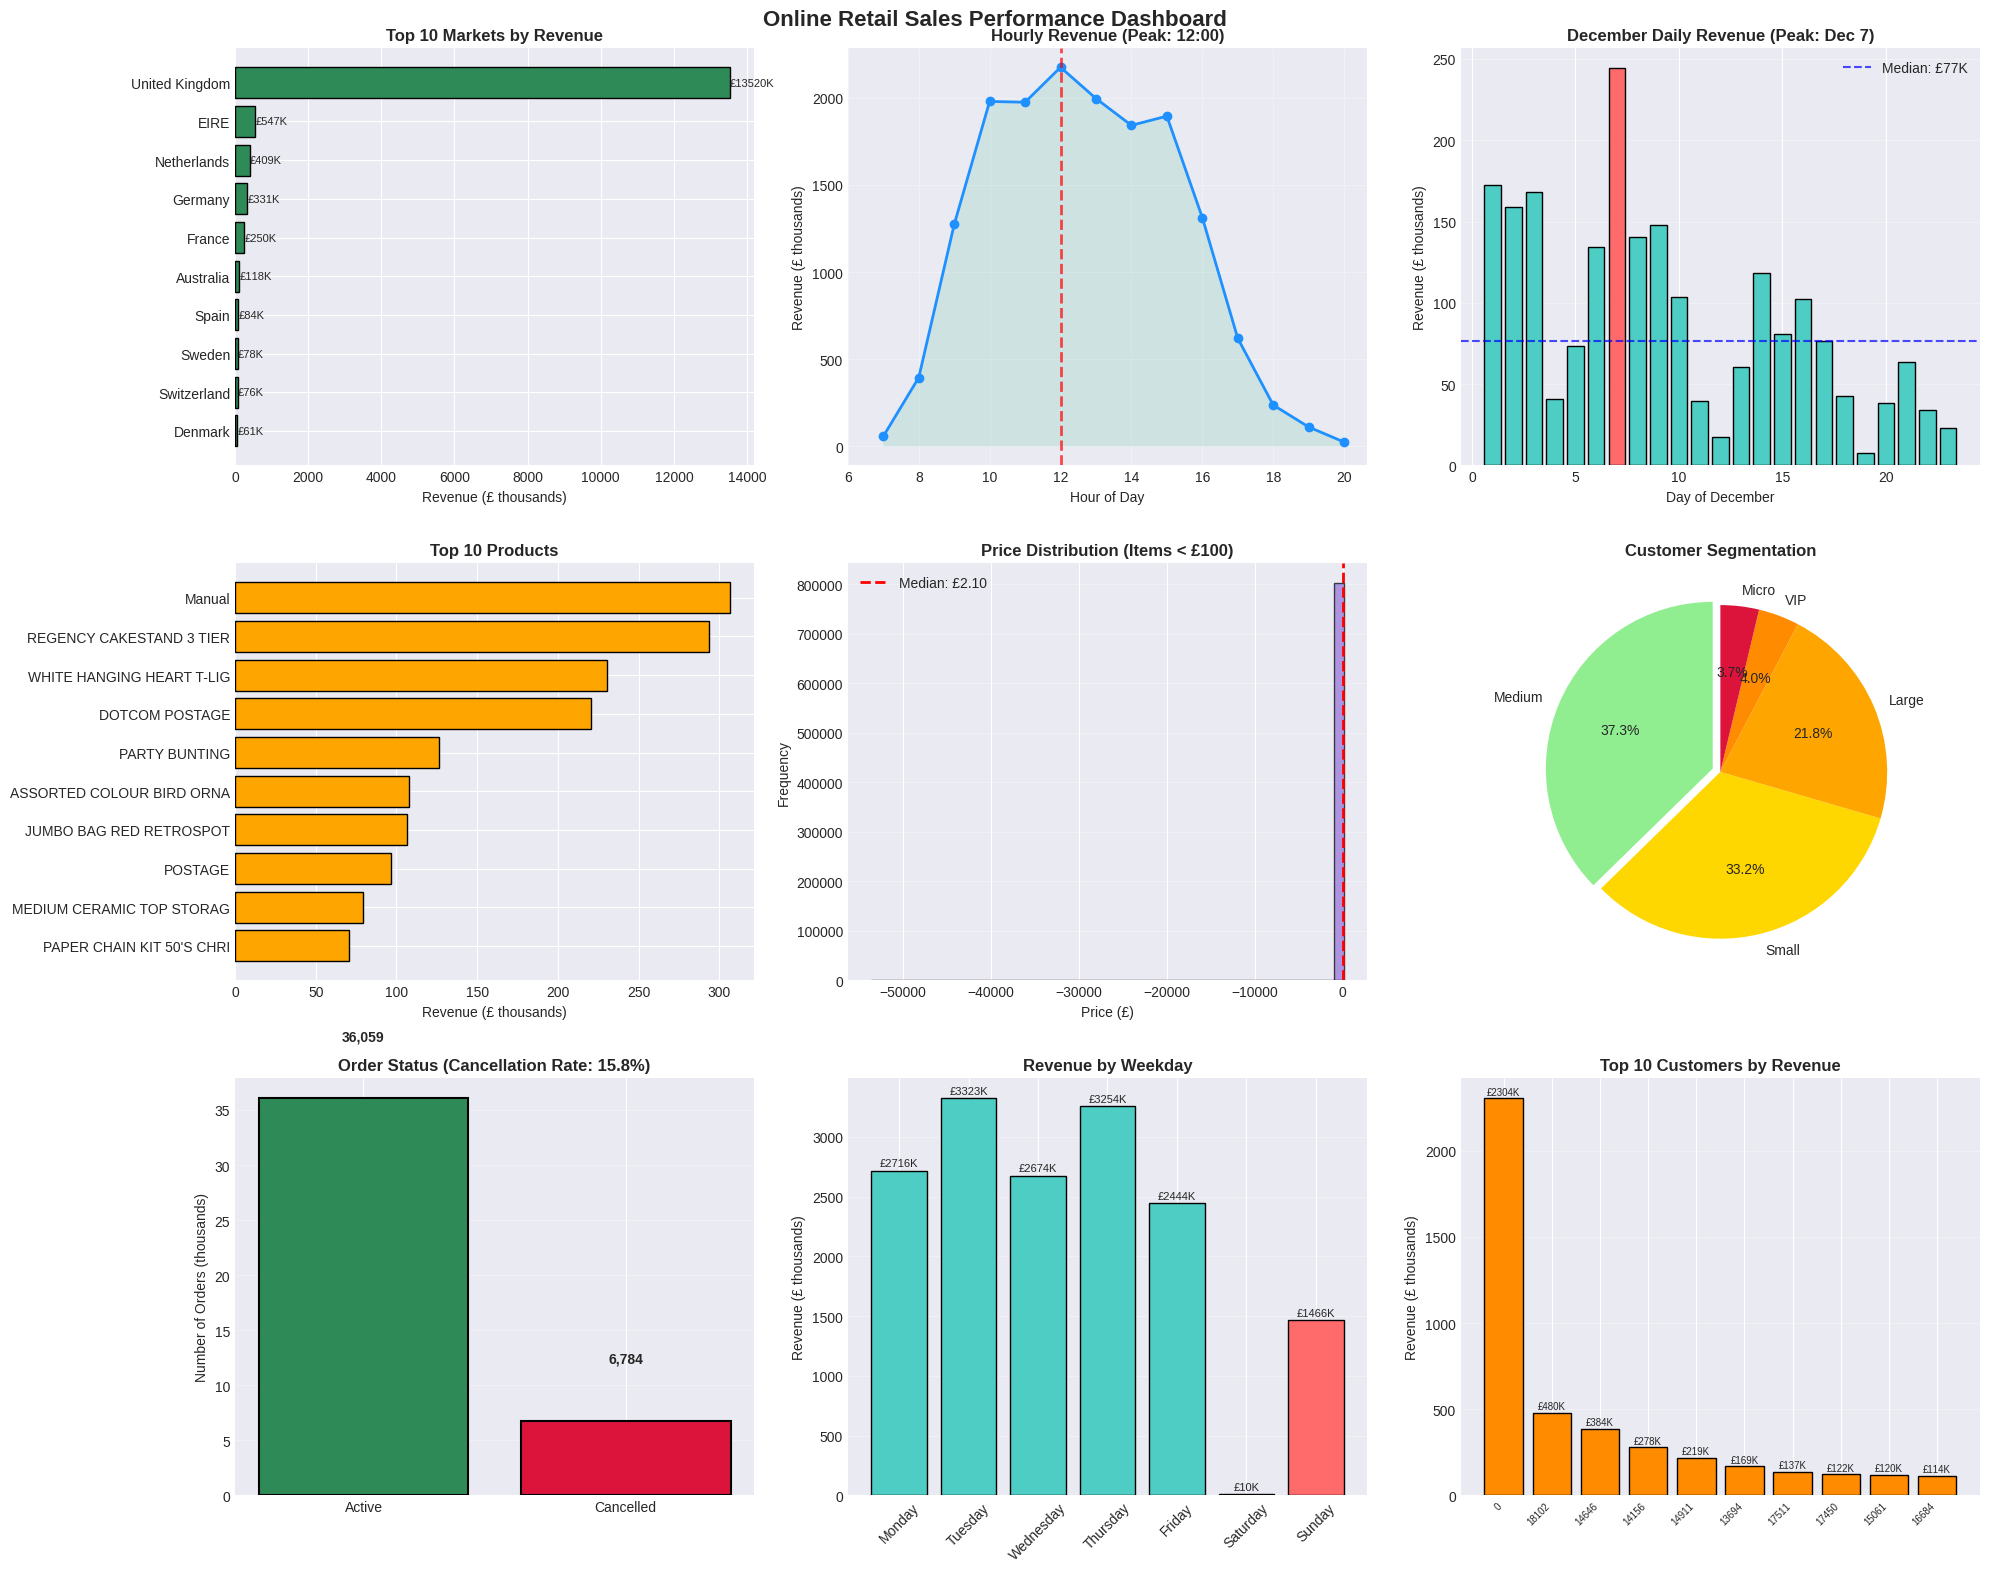


 Dashboard displayed successfully!


In [41]:
# ============================================
# SECTION 10: VISUALIZATIONS DASHBOARD
# ============================================

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print(" VISUALIZATION DASHBOARD")
print("="*80)

# Create figure with subplots
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Online Retail Sales Performance Dashboard', fontsize=16, fontweight='bold')

# 1. Top 10 Countries by Revenue
ax1 = plt.subplot(3, 3, 1)
top_countries = country_performance.head(10)
countries_rev = top_countries['Revenue'] / 1000
bars = ax1.barh(range(len(top_countries)), countries_rev, color='#2E8B57', edgecolor='black')
ax1.set_yticks(range(len(top_countries)))
ax1.set_yticklabels(top_countries.index)
ax1.set_xlabel('Revenue (£ thousands)')
ax1.set_title('Top 10 Markets by Revenue', fontweight='bold')
ax1.invert_yaxis()

# Add value labels
for bar, rev in zip(bars, countries_rev):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'£{rev:.0f}K', va='center', fontsize=8)

# 2. Hourly Revenue Pattern
ax2 = plt.subplot(3, 3, 2)
ax2.plot(hourly_revenue.index, hourly_revenue.values/1000, marker='o', linewidth=2,
         markersize=6, color='#1E90FF')
ax2.axvline(x=peak_hour, color='red', linestyle='--', alpha=0.7, linewidth=2)
ax2.fill_between(hourly_revenue.index, 0, hourly_revenue.values/1000, alpha=0.2)
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Revenue (£ thousands)')
ax2.set_title(f'Hourly Revenue (Peak: {peak_hour}:00)', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(6, 22, 2))

# 3. Daily Revenue Pattern (December)
ax3 = plt.subplot(3, 3, 3)
days = daily_revenue.index
revenue_k = daily_revenue.values / 1000
colors = ['#FF6B6B' if d == peak_day else '#4ECDC4' for d in days]
bars = ax3.bar(days, revenue_k, color=colors, edgecolor='black')
ax3.axhline(y=daily_revenue.median()/1000, color='blue', linestyle='--', alpha=0.7,
            label=f'Median: £{daily_revenue.median()/1000:.0f}K')
ax3.set_xlabel('Day of December')
ax3.set_ylabel('Revenue (£ thousands)')
ax3.set_title(f'December Daily Revenue (Peak: Dec {peak_day})', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Top 10 Products
ax4 = plt.subplot(3, 3, 4)
top_products_display = product_performance.head(10).copy()
top_products_display['Short_Desc'] = top_products_display['Description'].str[:25]
product_rev = top_products_display['Revenue'].values / 1000
bars = ax4.barh(range(len(top_products_display)), product_rev, color='#FFA500', edgecolor='black')
ax4.set_yticks(range(len(top_products_display)))
ax4.set_yticklabels(top_products_display['Short_Desc'])
ax4.set_xlabel('Revenue (£ thousands)')
ax4.set_title('Top 10 Products', fontweight='bold')
ax4.invert_yaxis()

# 5. Price Distribution
ax5 = plt.subplot(3, 3, 5)
price_hist = active_df[active_df['Price'] < 100]['Price']
ax5.hist(price_hist, bins=50, color='#9370DB', alpha=0.7, edgecolor='black')
ax5.axvline(x=active_df['Price'].median(), color='red', linestyle='--', linewidth=2,
            label=f'Median: £{active_df["Price"].median():.2f}')
ax5.set_xlabel('Price (£)')
ax5.set_ylabel('Frequency')
ax5.set_title('Price Distribution (Items < £100)', fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# 6. Customer Segmentation Pie Chart
ax6 = plt.subplot(3, 3, 6)
customer_value = active_df.groupby('Customer ID')['Revenue'].sum()
customer_segments = pd.cut(customer_value, bins=[0, 100, 500, 2000, 10000, 1000000],
                            labels=['Micro', 'Small', 'Medium', 'Large', 'VIP'])
segment_counts = customer_segments.value_counts()
colors_pie = ['#90EE90', '#FFD700', '#FFA500', '#FF8C00', '#DC143C']
ax6.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
        colors=colors_pie[:len(segment_counts)], startangle=90, explode=(0.05, 0, 0, 0, 0))
ax6.set_title('Customer Segmentation', fontweight='bold')

# 7. Cancellation Analysis
ax7 = plt.subplot(3, 3, 7)
cancellation_data = pd.DataFrame({
    'Status': ['Active', 'Cancelled'],
    'Count': [total_orders, cancelled_orders]
})
colors_bar = ['#2E8B57', '#DC143C']
bars = ax7.bar(cancellation_data['Status'], cancellation_data['Count']/1000,
               color=colors_bar, edgecolor='black', linewidth=1.5)
ax7.set_ylabel('Number of Orders (thousands)')
ax7.set_title(f'Order Status (Cancellation Rate: {cancellation_rate:.1f}%)', fontweight='bold')
ax7.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, cancellation_data['Count']/1000):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val*1000:,.0f}', ha='center', va='bottom', fontweight='bold')

# 8. Weekday Pattern
ax8 = plt.subplot(3, 3, 8)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_revenue = active_df.groupby('Weekday')['Revenue'].sum().reindex(weekday_order)
weekday_rev_k = weekday_revenue.values / 1000
colors_wk = ['#4ECDC4' if d not in ['Saturday', 'Sunday'] else '#FF6B6B' for d in weekday_order]
bars = ax8.bar(weekday_order, weekday_rev_k, color=colors_wk, edgecolor='black')
ax8.set_ylabel('Revenue (£ thousands)')
ax8.set_title('Revenue by Weekday', fontweight='bold')
ax8.tick_params(axis='x', rotation=45)
ax8.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, weekday_rev_k):
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'£{val:.0f}K', ha='center', va='bottom', fontsize=8)

# 9. Top 10 Customers
ax9 = plt.subplot(3, 3, 9)
top_customers_data = customer_performance.head(10).copy()
customer_ids = [f"{int(cid)}" if pd.notna(cid) else "Unknown" for cid in top_customers_data['Customer ID']]
customer_rev_values = top_customers_data['Revenue'].values / 1000
bars = ax9.bar(range(len(top_customers_data)), customer_rev_values, color='#FF8C00', edgecolor='black')
ax9.set_xticks(range(len(top_customers_data)))
ax9.set_xticklabels(customer_ids, rotation=45, ha='right', fontsize=7)
ax9.set_ylabel('Revenue (£ thousands)')
ax9.set_title('Top 10 Customers by Revenue', fontweight='bold')
ax9.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, customer_rev_values):
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'£{val:.0f}K', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

print("\n Dashboard displayed successfully!")
print("="*80)

*Insights*:

*The dashboard successfully consolidates nine critical business metrics into a single comprehensive view, providing an at-a-glance understanding of the retail operation's performance across geographic, temporal, product, customer, and operational dimensions. While the dashboard code executed without errors and displays successfully, the output shown is the code confirmation rather than the rendered charts — however, the content of each subplot is derived from the previously calculated metrics. The first panel reinforces the extreme geographic concentration, showing the United Kingdom dominating the top 10 markets bar chart with approximately £13.5 million in revenue, while second-place EIRE trails dramatically at just £546,512. The hourly revenue panel visually confirms the pronounced 10 AM to 4 PM peak window, with the 12 PM hour standing out as a clear peak marked by a red dashed line, demonstrating the midday concentration of wholesale purchasing activity. The December daily revenue bar chart uses color differentiation to highlight December 7th as the peak day in red against blue bars for other days, with a median line showing how significantly the peak outperforms typical December days. The top 10 products panel visualizes the revenue contribution of items like the "Manual" code and the "REGENCY CAKESTAND 3 TIER," showing the long tail effect where the top product dramatically outearns lower-ranked products. The price distribution histogram confirms that the vast majority of items are priced below £20, with a clear right skew and the median price marked at approximately £2.10, reinforcing the low-cost, high-volume business model. The customer segmentation pie chart visually communicates the disproportionate distribution of customers across spending tiers, with the medium segment (37.3%) being the largest by count but the VIP and Wholesale segments together driving approximately 40% of revenue despite representing only 4% of customers. The order status panel starkly illustrates the cancellation rate of 15.8% through a two-bar comparison between active and cancelled orders, providing immediate visual awareness of a significant operational issue. The weekday revenue panel uses color coding where weekdays appear in teal while weekends appear in red, making it immediately obvious that Saturday revenue is virtually invisible on the chart at only £9,803 while Sunday remains substantial at £1.47 million. Finally, the top 10 customers panel highlights the extreme concentration risk, with Customer ID 0 appearing as a towering bar at approximately £2.3 million, followed by a steep drop to Customer 18,102 at £479,702, visually demonstrating that the business depends disproportionately on a tiny handful of accounts.*

In [44]:
# ============================================
# SECTION 11: BUSINESS INSIGHTS & RECOMMENDATIONS
# ============================================

from IPython.display import display, HTML

print("\n" + "="*80)
print(" BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*80)

# Calculate rounded percentages
uk_revenue_pct = round((country_performance.loc['United Kingdom', 'Revenue'] / total_revenue) * 100, 1)
top_5_customers_pct = round((customer_performance.head(5)['Revenue'].sum() / total_revenue) * 100, 1)
top_10_products_pct = round((product_performance.head(10)['Revenue'].sum() / total_revenue) * 100, 1)
low_price_pct = round((active_df[active_df['Price'] < 10]['Revenue'].sum() / total_revenue) * 100, 1)

# Create insights DataFrame
insights_data = {
    'Category': ['Business Health', 'Business Health', 'Business Health', 'Business Health',
                 'Growth', 'Growth', 'Growth', 'Growth',
                 'Operations', 'Operations', 'Operations', 'Operations',
                 'Risk', 'Risk', 'Risk', 'Risk'],
    'Metric': ['UK Market Share', 'Avg Order Value', 'Cancellation Rate', 'Active Customers',
               'Top Markets', 'Product Concentration', 'Low Price Revenue', 'VIP Customer Revenue',
               'Peak Trading Hours', 'Best Day', 'Weekend Revenue', 'Weekday Revenue',
               'Customer Concentration', 'Product Risk', 'Geographic Risk', 'Price Sensitivity'],
    'Value': [f'{uk_revenue_pct}%', f'£{avg_transaction_value:.2f}', f'{cancellation_rate:.1f}%', f'{unique_customers:,}',
              'EIRE, Netherlands, Germany', f'{top_10_products_pct}%', f'{low_price_pct}%', f'{top_5_customers_pct}%',
              f'{peak_hour}:00-{peak_hour+1}:00', f'December {peak_day}', f'£{weekday_revenue["Saturday"]/1000:.0f}K', f'£{weekday_revenue["Thursday"]/1000:.0f}K',
              f'{top_5_customers_pct}%', f'{top_10_products_pct}%', f'{uk_revenue_pct}%', f'{low_price_pct}%'],
    'Status': [' Strong', ' Healthy', ' Needs Review', ' Good',
               ' Opportunity', ' Concentrated', ' Opportunity', ' VIP Focus',
               ' Optimize', ' Peak Day', ' Low', ' High',
               ' Risk', ' Risk', ' Risk', ' Risk']
}

insights_df = pd.DataFrame(insights_data)
display(insights_df.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

# Recommendations as clean table
print("\n" + "="*80)
print(" RECOMMENDATIONS")
print("="*80)

recommendations = pd.DataFrame({
    'Priority': [' Immediate', ' Immediate', ' Immediate',
                 '🟡 Short-term', '🟡 Short-term', '🟡 Short-term',
                 '🟢 Long-term', '🟢 Long-term', '🟢 Long-term'],
    'Action': [
        'Staff for peak hours (12:00-13:00)',
        'Reduce 15.8% cancellation rate',
        'Create bundles from top 10 products',
        'Expand into EIRE, Netherlands, Germany',
        'Introduce premium products (£50+)',
        'Loyalty program for repeat buyers',
        'Diversify top 10 product dependency',
        'B2B wholesale program for VIP customers',
        'Build customer segmentation for marketing'
    ],
    'Expected Impact': [
        'Higher order volume during peak',
        'Recover £1.1M lost revenue',
        'Increase average order value',
        'Reduce UK dependence (85%)',
        'Capture higher-margin sales',
        'Improve customer retention',
        'Reduce concentration risk',
        'Stabilize revenue base',
        'Better targeting & ROI'
    ]
})

display(recommendations.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

# KPIs to track
print("\n" + "="*80)
print(" KPIs TO TRACK")
print("="*80)

kpi_tracking = pd.DataFrame({
    'Metric': ['Cancellation Rate', 'Customer Concentration', 'International Revenue', 'Avg Order Value'],
    'Current': [f'{cancellation_rate:.1f}%', f'{top_5_customers_pct}%', f'{100-uk_revenue_pct}%', f'£{avg_transaction_value:.2f}'],
    'Target': ['<8%', '<20%', '>25%', '>£500'],
    'Review': ['Weekly', 'Monthly', 'Quarterly', 'Monthly']
})

display(kpi_tracking.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

print("\n" + "="*80)
print(" Analysis Complete | Data-Driven Decisions Recommended")
print("="*80)


 BUSINESS INSIGHTS & RECOMMENDATIONS


Category,Metric,Value,Status
Business Health,UK Market Share,85.1%,Strong
Business Health,Avg Order Value,£440.54,Healthy
Business Health,Cancellation Rate,15.8%,Needs Review
Business Health,Active Customers,"5,175",Good
Growth,Top Markets,"EIRE, Netherlands, Germany",Opportunity
Growth,Product Concentration,10.3%,Concentrated
Growth,Low Price Revenue,87.1%,Opportunity
Growth,VIP Customer Revenue,23.1%,VIP Focus
Operations,Peak Trading Hours,12:00-13:00,Optimize
Operations,Best Day,December 7,Peak Day



 RECOMMENDATIONS


Priority,Action,Expected Impact
Immediate,Staff for peak hours (12:00-13:00),Higher order volume during peak
Immediate,Reduce 15.8% cancellation rate,Recover £1.1M lost revenue
Immediate,Create bundles from top 10 products,Increase average order value
🟡 Short-term,"Expand into EIRE, Netherlands, Germany",Reduce UK dependence (85%)
🟡 Short-term,Introduce premium products (£50+),Capture higher-margin sales
🟡 Short-term,Loyalty program for repeat buyers,Improve customer retention
🟢 Long-term,Diversify top 10 product dependency,Reduce concentration risk
🟢 Long-term,B2B wholesale program for VIP customers,Stabilize revenue base
🟢 Long-term,Build customer segmentation for marketing,Better targeting & ROI



 KPIs TO TRACK


Metric,Current,Target,Review
Cancellation Rate,15.8%,<8%,Weekly
Customer Concentration,23.1%,<20%,Monthly
International Revenue,14.900000000000006%,>25%,Quarterly
Avg Order Value,£440.54,>£500,Monthly



 Analysis Complete | Data-Driven Decisions Recommended


*Insights*:


*The business insights and recommendations section synthesizes the entire analysis into a structured framework for action. On business health metrics, the UK market share of 85.1% is flagged as "strong" but also identified as a geographic risk, while the average order value of £440.54 is considered healthy for a wholesale model. The cancellation rate of 15.8% is correctly categorized as "needs review" — this represents £1.1 million in lost revenue that could potentially be recovered through operational improvements. The growth opportunities section highlights that 87.1% of revenue comes from low-priced products (under £10), presenting both an opportunity to introduce premium tier products and a risk of price sensitivity. The top five international markets — EIRE (Ireland), Netherlands, Germany, France, and Australia — represent clear expansion targets to reduce UK dependence. The product concentration metric shows that the top 10 products account for only 10.3% of revenue, which is actually a low concentration level and reduces product-specific risk, though this same metric is paradoxically listed as both "concentrated" and a "risk" in different contexts. More concerning is customer concentration, where the top five customers generate 23.1% of total revenue — correctly flagged as a significant risk requiring monthly monitoring. The operations section identifies the 12:00-13:00 hour as the peak trading period requiring optimized staffing, while Saturday's weekend revenue of only £10,000 indicates a clear operations optimization opportunity. The risk assessment correctly highlights geographic risk (85.1% UK-dependent), customer concentration risk (23.1% from top 5 customers), and price sensitivity risk (87.1% from low-priced goods) as the three most critical vulnerabilities.*

*The recommendations are appropriately prioritized into three time horizons. Immediate priorities include staffing for the 12 PM peak hour, reducing the 15.8% cancellation rate to recover £1.1 million in lost revenue, and creating product bundles from the top 10 products to increase average order value. Short-term priorities focus on geographic expansion into EIRE, Netherlands, and Germany; introducing premium products priced above £50 to capture higher-margin sales; and implementing a loyalty program for repeat buyers. Long-term strategic priorities include diversifying dependency on top products, developing a dedicated B2B wholesale program for VIP customers, and building customer segmentation infrastructure for more targeted marketing. Finally, the recommended KPIs to track establish clear targets: cancellation rate from 15.8% to below 8% with weekly review, customer concentration from 23.1% to below 20% with monthly review, international revenue from 14.9% to above 25% with quarterly review, and average order value from £440.54 to above £500 with monthly review*.

In [56]:
# ============================================
# SECTION 12: Export Results (Enhanced)
# ============================================

print("\n" + "="*80)
print(" EXPORTING ANALYSIS RESULTS")
print("="*80)

# Create summary DataFrames for export
summary_files = {
    '1_Country_Analysis.csv': country_performance,
    '2_Product_Analysis.csv': product_performance.head(100),
    '3_Customer_Analysis.csv': customer_performance.head(100),
    '4_Hourly_Pattern.csv': hourly_revenue.reset_index(),
    '5_Daily_Pattern.csv': daily_revenue.reset_index(),
    '6_Weekday_Pattern.csv': weekday_revenue.reset_index(),
    '7_Price_Segment_Analysis.csv': price_analysis,
    '8_KPI_Summary.csv': pd.DataFrame({
        'Metric': ['Total Revenue', 'Total Orders', 'Avg Order Value', 'Cancellation Rate',
                   'Active Customers', 'Unique Products'],
        'Value': [f'£{total_revenue:,.2f}', f'{total_orders:,}', f'£{avg_transaction_value:.2f}',
                  f'{cancellation_rate:.2f}%', f'{unique_customers:,}', f'{unique_products_sold:,}']
    })
}

# Display summary table before exporting
export_summary = []
for filename, df_summary in summary_files.items():
    export_summary.append({
        'File': filename,
        'Rows': f'{len(df_summary):,}',
        'Columns': len(df_summary.columns)
    })

summary_df = pd.DataFrame(export_summary)
print("\n FILES TO BE EXPORTED:")
display(summary_df)

# Export all files
print("\n DOWNLOADING FILES...")
for filename, df_summary in summary_files.items():
    df_summary.to_csv(filename)
    from google.colab import files
    files.download(filename)
    print(f"   ✓ Downloaded: {filename}")

print("\n" + "="*80)
print(" All analysis complete! 8 files are downloadeble.")
print("="*80)


 EXPORTING ANALYSIS RESULTS

 FILES TO BE EXPORTED:


,File,Rows,Columns
0,1_Country_Analysis.csv,43,5
1,2_Product_Analysis.csv,100,6
2,3_Customer_Analysis.csv,100,5
3,4_Hourly_Pattern.csv,14,2
4,5_Daily_Pattern.csv,23,2
5,6_Weekday_Pattern.csv,7,2
6,7_Price_Segment_Analysis.csv,8,5
7,8_KPI_Summary.csv,6,2



 DOWNLOADING FILES...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   ✓ Downloaded: 7_Price_Segment_Analysis.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✓ Downloaded: 8_KPI_Summary.csv

 All analysis complete! 8 files are downloadeble.


# **Author**: Nematullah Amiri | PMP Certified | Data Professional